In [28]:
import os
import re
from pathlib import Path
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

pio_fields = ["participants", "interventions", "outcomes"]
DATA_DIR = Path("./ebm_nlp_2_00")

model_order = [
    "rule_based",
    "biobert",
    "pubmedbert",
    "clinicalbert",
    "decomposed",
    "fewshot_qwen",
    "zeroshot_qwen"
]

# ----------------------------
# get official test doc ids
# ----------------------------
def get_doc_ids(split="test", label_type="participants"):
    if split == "test":
        split = "test/gold"

    folder = (
        DATA_DIR
        / "annotations"
        / "aggregated"
        / "starting_spans"
        / label_type
        / split
    )

    doc_ids = [p.stem.split(".")[0] for p in folder.glob("*.AGGREGATED.ann")]
    return sorted(doc_ids)


test_doc_ids_p = get_doc_ids("test", "participants")
test_doc_ids_i = get_doc_ids("test", "interventions")
test_doc_ids_o = get_doc_ids("test", "outcomes")

test_doc_ids = sorted(set(test_doc_ids_p) & set(test_doc_ids_i) & set(test_doc_ids_o))

print("Participants test docs:", len(test_doc_ids_p))
print("Interventions test docs:", len(test_doc_ids_i))
print("Outcomes test docs:", len(test_doc_ids_o))
print("Common test docs used for final gold:", len(test_doc_ids))

# ----------------------------
# build gold csv
# ----------------------------
def get_spans(tokens, labels):
    spans = []
    current = []

    for tok, lab in zip(tokens, labels):
        lab = int(lab)

        if lab != 0:
            current.append(tok)
        else:
            if current:
                spans.append(" ".join(current))
                current = []

    if current:
        spans.append(" ".join(current))

    return spans


def read_tokens(doc_id):
    path = DATA_DIR / "documents" / f"{doc_id}.tokens"
    with open(path, "r", encoding="utf-8") as f:
        return [line.strip() for line in f]


def read_labels(doc_id, field, split="test"):
    if split == "test":
        split = "test/gold"

    path = (
        DATA_DIR
        / "annotations"
        / "aggregated"
        / "starting_spans"
        / field
        / split
        / f"{doc_id}.AGGREGATED.ann"
    )

    with open(path, "r", encoding="utf-8") as f:
        return [line.strip() for line in f]


def build_one_doc(doc_id):
    tokens = read_tokens(doc_id)
    row = {"doc_id": str(doc_id)}

    for field in pio_fields:
        labels = read_labels(doc_id, field)
        spans = get_spans(tokens, labels)

        seen = set()
        clean_spans = []
        for s in spans:
            if s not in seen:
                seen.add(s)
                clean_spans.append(s)

        row[f"{field}_gold"] = " ; ".join(clean_spans)

    return row


def build_gold(doc_ids):
    rows = []

    for d in doc_ids:
        try:
            rows.append(build_one_doc(d))
        except Exception as e:
            print(f"Skipping {d}: {e}")

    return pd.DataFrame(rows)


gold_df = build_gold(test_doc_ids)
gold_df.to_csv("gold_structured.csv", index=False)
print("Gold csv saved.")

# ----------------------------
# text helpers
# ----------------------------
def clean_text(txt):
    if pd.isna(txt):
        return ""

    txt = str(txt).lower().strip()
    txt = txt.replace("[", "").replace("]", "")
    txt = txt.replace("|", " ; ")
    txt = re.sub(r"\s+", " ", txt).strip()

    return txt


def clean_span(txt):
    txt = clean_text(txt)
    txt = re.sub(r"[^\w\s]", " ", txt)
    txt = re.sub(r"\s+", " ", txt).strip()
    return txt


def split_spans(txt):
    txt = clean_text(txt)

    if txt == "":
        return []

    raw_spans = [s.strip() for s in txt.split(";")]

    spans = []
    seen = set()

    for s in raw_spans:
        s2 = clean_span(s)
        if s2 != "" and s2 not in seen:
            spans.append(s2)
            seen.add(s2)

    return spans


# ----------------------------
# prep prediction csvs
# ----------------------------
def join_gold_and_preds(gold_csv_path, pred_csv_path, variant_label):
    gold_tab = pd.read_csv(gold_csv_path, dtype={"doc_id": str})
    pred_tab = pd.read_csv(pred_csv_path, dtype={"doc_id": str})

    merged = gold_tab.merge(pred_tab, on="doc_id", how="left")

    for col in ["participants_pred", "interventions_pred", "outcomes_pred"]:
        if col not in merged.columns:
            merged[col] = ""
        merged[col] = merged[col].fillna("")

    merged["variant"] = variant_label
    return merged


def stack_variants(list_of_tabs):
    return pd.concat(list_of_tabs, ignore_index=True)


def check_expected_columns(tab, fields):
    needed = ["doc_id", "variant"]

    for fld in fields:
        needed.append(f"{fld}_gold")
        needed.append(f"{fld}_pred")

    missing = [c for c in needed if c not in tab.columns]

    if missing:
        print("Missing columns:")
        for c in missing:
            print("-", c)
    else:
        print("All expected columns are present.")


# ----------------------------
# merge current model csvs
# ----------------------------
tab_rule = join_gold_and_preds(
    "gold_structured.csv",
    "./results_axis1A_rule_based.csv",
    "rule_based"
)

tab_decomposed = join_gold_and_preds(
    "gold_structured.csv",
    "./Axis2B_FULL_SUBMISSION.csv",
    "decomposed"
)

tab_biobert = join_gold_and_preds(
    "gold_structured.csv",
    "./axis1B_BioBERT_pred.csv",
    "biobert"
)

tab_pubmedbert = join_gold_and_preds(
    "gold_structured.csv",
    "./axis1B_PubMedBERT_pred.csv",
    "pubmedbert"
)

tab_clinicalbert = join_gold_and_preds(
    "gold_structured.csv",
    "./axis1B_BioClinical_ModernBERT_pred.csv",
    "clinicalbert"
)

tab_fewshot_qwen = join_gold_and_preds(
    "gold_structured.csv",
    "./axis2A_Few_Shot_qwen_pred.csv",
    "fewshot_qwen"
)

tab_zeroshot_qwen = join_gold_and_preds(
    "gold_structured.csv",
    "./axis2A_Zero_Shot_qwen_pred.csv",
    "zeroshot_qwen"
)

all_runs = stack_variants([
    tab_rule,
    tab_biobert,
    tab_pubmedbert,
    tab_clinicalbert,
    tab_decomposed,
    tab_fewshot_qwen,
    tab_zeroshot_qwen
])

all_runs["variant"] = pd.Categorical(all_runs["variant"], categories=model_order, ordered=True)
all_runs = all_runs.sort_values(["variant", "doc_id"]).reset_index(drop=True)

check_expected_columns(all_runs, pio_fields)
print(all_runs["variant"].value_counts().sort_index())

# ----------------------------
# matching metrics
# ----------------------------
def exact_m(gold_txt, pred_txt):
    g = clean_span(gold_txt)
    p = clean_span(pred_txt)
    return int(g != "" and g == p)


def overlap_f1(gold_txt, pred_txt):
    g = clean_span(gold_txt)
    p = clean_span(pred_txt)

    if g == "" and p == "":
        return 1.0
    if g == "" or p == "":
        return 0.0

    gold_tkn = g.split()
    pred_tkn = p.split()

    gold_count = defaultdict(int)
    pred_count = defaultdict(int)

    for w in gold_tkn:
        gold_count[w] += 1

    for w in pred_tkn:
        pred_count[w] += 1

    shared = 0
    for w in gold_count:
        shared += min(gold_count[w], pred_count[w])

    if shared == 0:
        return 0.0

    prec = shared / len(pred_tkn)
    rec = shared / len(gold_tkn)

    return 2 * prec * rec / (prec + rec)


# ----------------------------
# compare every gold span with every pred span
# ----------------------------
def match_spans(gold_spans, pred_spans, match_threshold=0.5):
    if len(gold_spans) == 0 and len(pred_spans) == 0:
        return 0, 0, 0

    pairs = []

    for g_idx, g in enumerate(gold_spans):
        for p_idx, p in enumerate(pred_spans):
            score = overlap_f1(g, p)
            if score >= match_threshold:
                pairs.append((score, g_idx, p_idx))

    pairs.sort(reverse=True, key=lambda pair: pair[0])

    used_gold = set()
    used_pred = set()

    for score, g_idx, p_idx in pairs:
        if g_idx not in used_gold and p_idx not in used_pred:
            used_gold.add(g_idx)
            used_pred.add(p_idx)

    tp = len(used_gold)
    fp = len(pred_spans) - tp
    fn = len(gold_spans) - tp

    return tp, fp, fn


# ----------------------------
# evaluate one field
# ----------------------------
def evaluate_1field(tab, gold_col, pred_col, match_threshold=0.5):
    gold_nonempty = 0
    pred_nonempty = 0
    covered = 0

    exact_score = []
    field_f1_score = []

    tp_all = 0
    fp_all = 0
    fn_all = 0

    for _, row in tab.iterrows():
        g_txt = row[gold_col]
        p_txt = row[pred_col]

        exact_score.append(exact_m(g_txt, p_txt))
        field_f1_score.append(overlap_f1(g_txt, p_txt))

        gold_spans = split_spans(g_txt)
        pred_spans = split_spans(p_txt)

        has_gold = len(gold_spans) > 0
        has_pred = len(pred_spans) > 0

        if has_gold:
            gold_nonempty += 1
        if has_pred:
            pred_nonempty += 1
        if has_gold and has_pred:
            covered += 1

        tp, fp, fn = match_spans(
            gold_spans,
            pred_spans,
            match_threshold=match_threshold
        )

        tp_all += tp
        fp_all += fp
        fn_all += fn

    span_precision = tp_all / (tp_all + fp_all) if (tp_all + fp_all) > 0 else 0.0
    span_recall = tp_all / (tp_all + fn_all) if (tp_all + fn_all) > 0 else 0.0
    span_f1 = 2 * span_precision * span_recall / (span_precision + span_recall) if (span_precision + span_recall) > 0 else 0.0
    coverage = covered / gold_nonempty if gold_nonempty > 0 else 0.0

    return {
        "field": gold_col.replace("_gold", ""),
        "exact_match": np.mean(exact_score),
        "field_f1": np.mean(field_f1_score),
        "span_precision": span_precision,
        "span_recall": span_recall,
        "span_f1": span_f1,
        "coverage": coverage,
        "gold_nonempty": gold_nonempty,
        "pred_nonempty": pred_nonempty,
        "tp_spans": tp_all,
        "fp_spans": fp_all,
        "fn_spans": fn_all
    }


# ----------------------------
# evaluate one variant
# ----------------------------
def eval_variant(tab, fields, variant_name, match_threshold=0.5):
    rows = []

    for fld in fields:
        row = evaluate_1field(
            tab,
            gold_col=f"{fld}_gold",
            pred_col=f"{fld}_pred",
            match_threshold=match_threshold
        )
        row["variant"] = variant_name
        rows.append(row)

    output = pd.DataFrame(rows)

    overall = {
        "variant": variant_name,
        "field": "overall_avg",
        "exact_match": output["exact_match"].mean(),
        "field_f1": output["field_f1"].mean(),
        "span_precision": output["span_precision"].mean(),
        "span_recall": output["span_recall"].mean(),
        "span_f1": output["span_f1"].mean(),
        "coverage": output["coverage"].mean(),
        "gold_nonempty": output["gold_nonempty"].sum(),
        "pred_nonempty": output["pred_nonempty"].sum(),
        "tp_spans": output["tp_spans"].sum(),
        "fp_spans": output["fp_spans"].sum(),
        "fn_spans": output["fn_spans"].sum()
    }

    return pd.concat([output, pd.DataFrame([overall])], ignore_index=True)


# ----------------------------
# evaluate all variants
# ----------------------------
def evaluate_all_variants(all_tab, fields, match_threshold=0.5):
    results = []

    for name, sub in all_tab.groupby("variant", observed=False):
        res = eval_variant(sub, fields, name, match_threshold)
        results.append(res)

    return pd.concat(results, ignore_index=True)


# ----------------------------
# downstream usability helpers
# ----------------------------
def simple_lemma(word):
    if word.endswith("ies") and len(word) > 4:
        return word[:-3] + "y"
    if word.endswith("ing") and len(word) > 5:
        return word[:-3]
    if word.endswith("ed") and len(word) > 4:
        return word[:-2]
    if word.endswith("s") and len(word) > 3:
        return word[:-1]
    return word


def lemma_text(txt):
    txt = clean_span(txt)
    words = txt.split()
    words = [simple_lemma(w) for w in words]
    return " ".join(words)


# ----------------------------
# downstream usability
# ----------------------------
def make_q_table(tab, use_pred=False):
    suffix = "_pred" if use_pred else "_gold"

    small_tab = tab[[
        "doc_id",
        f"participants{suffix}",
        f"interventions{suffix}",
        f"outcomes{suffix}"
    ]].copy()

    small_tab.columns = ["doc_id","participants","interventions","outcomes"]
    return small_tab


def score_1doc(row, must_have):
    score = 0

    for field, words in must_have.items():
        text = lemma_text(row[field])

        for w in words:
            w2 = lemma_text(w)
            if re.search(rf"\b{re.escape(w2)}\b", text):
                score += 1

    return score


def rank_doc(tab, must_have):
    work = tab.copy()
    work["score"] = work.apply(lambda row: score_1doc(row, must_have), axis=1)
    work = work[work["score"] > 0].copy()
    work = work.sort_values(["score","doc_id"], ascending=[False, True])
    return work[["doc_id","score"]]


def eval_1rq(gold_tab, pred_tab, query_item, top_k=10):
    gold_rank = rank_doc(gold_tab, query_item["must_have"])
    pred_rank = rank_doc(pred_tab, query_item["must_have"])

    gold_top = set(gold_rank.head(top_k)["doc_id"].tolist())
    pred_top = set(pred_rank.head(top_k)["doc_id"].tolist())

    tp = len(gold_top & pred_top)
    fp = len(pred_top - gold_top)
    fn = len(gold_top - pred_top)

    precision = tp/(tp+fp) if (tp+fp)>0 else 0.0
    recall = tp/(tp+fn) if (tp+fn)>0 else 0.0
    f1 = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0.0

    return {
        "query": query_item["name"],
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "gold_matches": len(gold_top),
        "pred_matches": len(pred_top)
    }


def success_1rq(gold_tab, pred_tab, query_item, top_k=10):
    gold_rank = rank_doc(gold_tab, query_item["must_have"])
    pred_rank = rank_doc(pred_tab, query_item["must_have"])

    gold_top = set(gold_rank.head(top_k)["doc_id"].tolist())
    pred_top = set(pred_rank.head(top_k)["doc_id"].tolist())

    success = int(len(gold_top & pred_top) > 0)

    return {
        "query": query_item["name"],
        "success": success,
        "gold_matches": len(gold_top),
        "pred_matches": len(pred_top)
    }


def eval_qranked(gold_tab, pred_tab, queries, top_k=10):
    rows = []

    for q in queries:
        rows.append(eval_1rq(gold_tab, pred_tab, q, top_k=top_k))

    output = pd.DataFrame(rows)

    overall = pd.DataFrame([{
        "query": "overall",
        "precision": output["precision"].mean(),
        "recall": output["recall"].mean(),
        "f1": output["f1"].mean(),
        "gold_matches": output["gold_matches"].sum(),
        "pred_matches": output["pred_matches"].sum()
    }])

    return pd.concat([output,overall], ignore_index=True)


def eval_q_success(gold_tab, pred_tab, queries, top_k=10):
    rows = []

    for q in queries:
        rows.append(success_1rq(gold_tab, pred_tab, q, top_k=top_k))

    output = pd.DataFrame(rows)

    overall = pd.DataFrame([{
        "query": "overall",
        "success": output["success"].mean(),
        "gold_matches": output["gold_matches"].sum(),
        "pred_matches": output["pred_matches"].sum()
    }])

    return pd.concat([output, overall], ignore_index=True)


def eval_q_allvariant(all_tab, queries, top_k=10):
    all_rows = []

    for v_name, sub_tab in all_tab.groupby("variant", observed=False):
        gold_q = make_q_table(sub_tab, use_pred=False)
        pred_q = make_q_table(sub_tab, use_pred=True)
        res = eval_qranked(gold_q, pred_q, queries, top_k=top_k)
        res["variant"] = v_name
        all_rows.append(res)

    return pd.concat(all_rows, ignore_index=True)


def eval_q_success_allvariant(all_tab, queries, top_k=10):
    all_rows = []

    for v_name, sub_tab in all_tab.groupby("variant", observed=False):
        gold_q = make_q_table(sub_tab, use_pred=False)
        pred_q = make_q_table(sub_tab, use_pred=True)
        res = eval_q_success(gold_q, pred_q, queries, top_k=top_k)
        res["variant"] = v_name
        all_rows.append(res)

    return pd.concat(all_rows, ignore_index=True)


# ----------------------------
# run evaluation
# ----------------------------
field_scores = evaluate_all_variants(all_runs, pio_fields, match_threshold=0.5)

field_order = ["participants","interventions","outcomes","overall_avg"]
field_scores["field"] = pd.Categorical(field_scores["field"], categories=field_order, ordered=True)
field_scores["variant"] = pd.Categorical(field_scores["variant"], categories=model_order, ordered=True)
field_scores = field_scores.sort_values(["field","variant"]).reset_index(drop=True)


Participants test docs: 189
Interventions test docs: 188
Outcomes test docs: 190
Common test docs used for final gold: 186
Gold csv saved.
All expected columns are present.
variant
rule_based       186
biobert          186
pubmedbert       186
clinicalbert     186
decomposed       186
fewshot_qwen     186
zeroshot_qwen    186
Name: count, dtype: int64


In [29]:

# ----------------------------
# main tables
# ----------------------------
table_span_f1 = field_scores.pivot_table(
    index="field",
    columns="variant",
    values="span_f1",
    observed=False
).reindex(field_order)

display(table_span_f1.round(3))

table_span_pc = field_scores.pivot_table(
    index="field",
    columns="variant",
    values=["span_precision","coverage"],
    observed=False
).reindex(field_order)

display(table_span_pc.round(3))

table_span_recall = field_scores.pivot_table(
    index="field",
    columns="variant",
    values="span_recall",
    observed=False
).reindex(field_order)

display(table_span_recall.round(3))

table_field = field_scores.pivot_table(
    index="field",
    columns="variant",
    values=["exact_match","field_f1"],
    observed=False
).reindex(field_order)

display(table_field.round(3))

# ----------------------------
# plots
# ----------------------------
def plot_span_f1(score_tab):
    fields = ["participants","interventions","outcomes"]

    for fld in fields:
        sub = score_tab[score_tab["field"] == fld].sort_values("variant")

        plt.figure(figsize=(8,4))
        plt.bar(sub["variant"].astype(str), sub["span_f1"])

        plt.xticks(rotation=30)
        plt.ylabel("Span F1")
        plt.title(f"{fld} - Span F1 by model")
        plt.grid(axis="y")
        plt.tight_layout()
        plt.show()


def plot_precision_recall(score_tab):
    fields = ["participants","interventions","outcomes"]

    for fld in fields:
        sub = score_tab[score_tab["field"] == fld].sort_values("variant")

        x = np.arange(len(sub))
        width = 0.35

        plt.figure(figsize=(10,4))
        plt.bar(x - width/2, sub["span_precision"], width, label="precision")
        plt.bar(x + width/2, sub["span_recall"], width, label="recall")

        plt.xticks(x, sub["variant"].astype(str), rotation=30)
        plt.ylabel("Score")
        plt.title(f"{fld} - Precision vs Recall")
        plt.legend()
        plt.grid(axis="y")
        plt.tight_layout()
        plt.show()


def plot_cvp_simple(score_tab):
    fields = ["participants","interventions","outcomes"]

    fig, axs = plt.subplots(1,3,figsize=(12,4))

    for i, fld in enumerate(fields):
        sub = score_tab[score_tab["field"] == fld].sort_values("variant")

        for _, row in sub.iterrows():
            axs[i].scatter(row["coverage"], row["span_precision"])
            axs[i].text(row["coverage"], row["span_precision"], str(row["variant"]), fontsize=7)

        axs[i].set_title(fld)
        axs[i].set_xlabel("coverage")
        axs[i].grid(True)

    axs[0].set_ylabel("precision")
    plt.tight_layout()
    plt.show()



variant,rule_based,biobert,pubmedbert,clinicalbert,decomposed,fewshot_qwen,zeroshot_qwen
field,,,,,,,
participants,0.283,0.156,0.318,0.159,0.134,0.391,0.360
interventions,0.073,0.180,0.279,0.162,0.448,0.165,0.164
outcomes,0.087,0.285,0.413,0.250,0.435,0.073,0.115
overall_avg,0.148,0.207,0.337,0.190,0.339,0.210,0.213


coverage                                             \
variant       rule_based biobert pubmedbert clinicalbert decomposed   
field                                                                 
participants       0.629   0.876      0.930        0.882      0.177   
interventions      0.774   0.946      0.952        0.952      0.726   
outcomes           0.608   0.952      0.952        0.952      0.876   
overall_avg        0.670   0.925      0.944        0.928      0.593   

                                         span_precision                     \
variant       fewshot_qwen zeroshot_qwen     rule_based biobert pubmedbert   
field                                                                        
participants         0.952         0.876          0.458   0.154      0.289   
interventions        0.935         0.871          0.117   0.154      0.245   
outcomes             0.952         0.860          0.338   0.324      0.437   
overall_avg          0.946         0.869          0.304   0.211      0.324   

                                                                  
variant       clinicalbert decomposed fewshot_qwen zeroshot_qwen  
field                                                             
participants         0.154      0.542        0.830         0.824  
interventions        0.142      0.652        0.465         0.517  
outcomes             0.282      0.763        0.292         0.445  
overall_avg          0.193      0.652        0.529         0.595

variant,rule_based,biobert,pubmedbert,clinicalbert,decomposed,fewshot_qwen,zeroshot_qwen
field,,,,,,,
participants,0.205,0.157,0.354,0.164,0.076,0.255,0.230
interventions,0.053,0.217,0.325,0.188,0.342,0.100,0.097
outcomes,0.050,0.254,0.392,0.224,0.304,0.042,0.066
overall_avg,0.103,0.209,0.357,0.192,0.241,0.133,0.131


exact_match                                             \
variant        rule_based biobert pubmedbert clinicalbert decomposed   
field                                                                  
participants          0.0     0.0        0.0          0.0      0.000   
interventions         0.0     0.0        0.0          0.0      0.011   
outcomes              0.0     0.0        0.0          0.0      0.000   
overall_avg           0.0     0.0        0.0          0.0      0.004   

                                           field_f1                     \
variant       fewshot_qwen zeroshot_qwen rule_based biobert pubmedbert   
field                                                                    
participants         0.022         0.016      0.246   0.242      0.379   
interventions        0.000         0.005      0.095   0.193      0.266   
outcomes             0.000         0.000      0.089   0.366      0.454   
overall_avg          0.007         0.007      0.143   0.267      0.367   

                                                                  
variant       clinicalbert decomposed fewshot_qwen zeroshot_qwen  
field                                                             
participants         0.260      0.077        0.433         0.408  
interventions        0.184      0.340        0.320         0.346  
outcomes             0.350      0.415        0.265         0.325  
overall_avg          0.265      0.277        0.339         0.360

f1                                  \
variant                     rule_based biobert pubmedbert clinicalbert   
query                                                                    
blood pressure outcomes          0.800   0.667       1.00        0.286   
diabetes and metformin           0.286   0.286       0.50        0.286   
diabetes participants            0.286   0.286       0.50        0.286   
exercise and blood pressure      0.600   0.778       0.90        0.429   
exercise interventions           0.333   0.889       0.75        0.571   
overall                          0.461   0.581       0.73        0.371   

                                                                   precision  \
variant                     decomposed fewshot_qwen zeroshot_qwen rule_based   
query                                                                          
blood pressure outcomes          0.857        0.769         0.800      0.667   
diabetes and metformin           0.286        0.286         0.500      1.000   
diabetes participants            0.286        0.286         0.500      1.000   
exercise and blood pressure      0.700        0.700         0.889      0.600   
exercise interventions           0.750        0.889         1.000      0.500   
overall                          0.576        0.586         0.738      0.753   

                                                ...                          \
variant                     biobert pubmedbert  ... decomposed fewshot_qwen   
query                                           ...                           
blood pressure outcomes       1.000       1.00  ...       0.75        0.714   
diabetes and metformin        1.000       1.00  ...       1.00        1.000   
diabetes participants         1.000       1.00  ...       1.00        1.000   
exercise and blood pressure   0.875       0.90  ...       0.70        0.700   
exercise interventions        0.800       0.75  ...       0.75        0.800   
overall                       0.935       0.93  ...       0.84        0.843   

                                              recall                     \
variant                     zeroshot_qwen rule_based biobert pubmedbert   
query                                                                     
blood pressure outcomes               1.0      1.000   0.500      1.000   
diabetes and metformin                1.0      0.167   0.167      0.333   
diabetes participants                 1.0      0.167   0.167      0.333   
exercise and blood pressure           1.0      0.600   0.700      0.900   
exercise interventions                1.0      0.250   1.000      0.750   
overall                               1.0      0.437   0.507      0.663   

                                                                                
variant                     clinicalbert decomposed fewshot_qwen zeroshot_qwen  
query                                                                           
blood pressure outcomes            0.167      1.000        0.833         0.667  
diabetes and metformin             0.167      0.167        0.167         0.333  
diabetes participants              0.167      0.167        0.167         0.333  
exercise and blood pressure        0.300      0.700        0.700         0.800  
exercise interventions             0.500      0.750        1.000         1.000  
overall                            0.260      0.557        0.573         0.627  

[6 rows x 21 columns]

variant,rule_based,biobert,pubmedbert,clinicalbert,decomposed,fewshot_qwen,zeroshot_qwen
query,,,,,,,
blood pressure outcomes,1.0,1.0,1.0,1.0,1.0,1.0,1.0
diabetes and metformin,1.0,1.0,1.0,1.0,1.0,1.0,1.0
diabetes participants,1.0,1.0,1.0,1.0,1.0,1.0,1.0
exercise and blood pressure,1.0,1.0,1.0,1.0,1.0,1.0,1.0
exercise interventions,1.0,1.0,1.0,1.0,1.0,1.0,1.0
overall,1.0,1.0,1.0,1.0,1.0,1.0,1.0


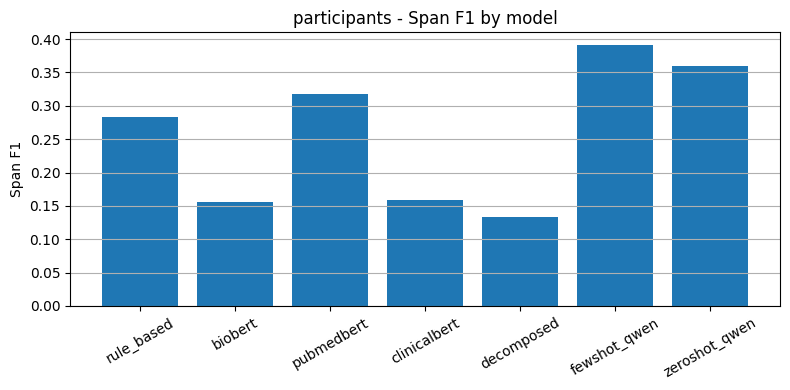

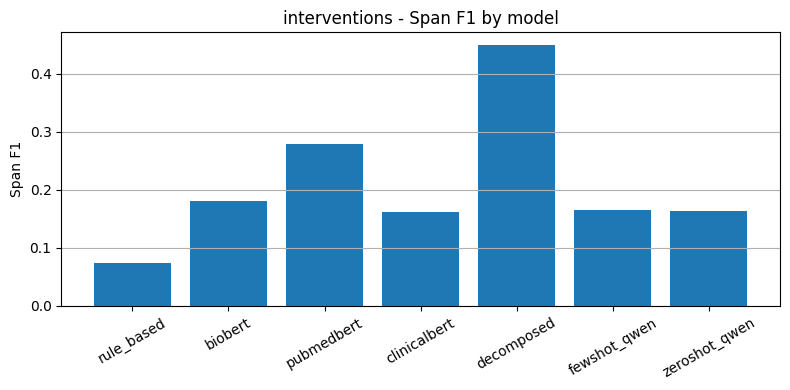

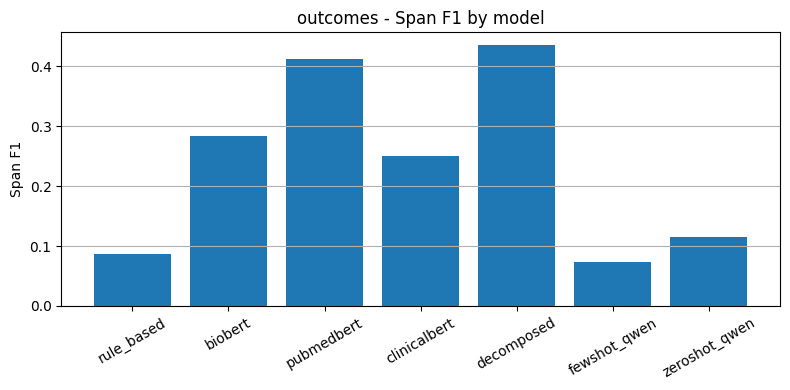

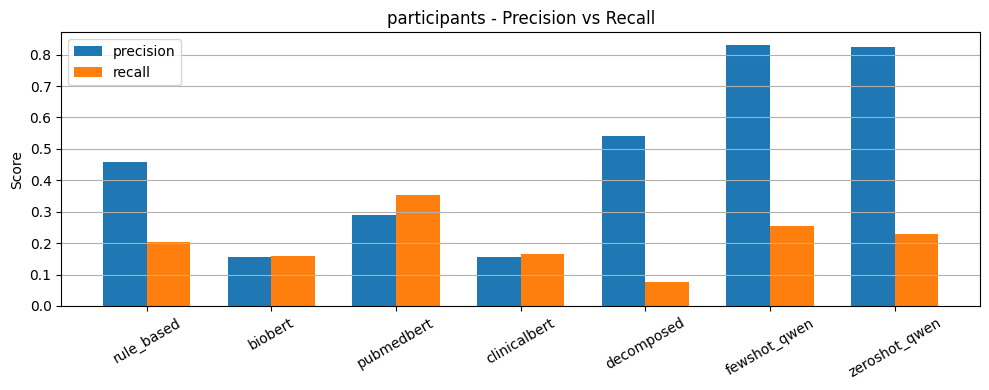

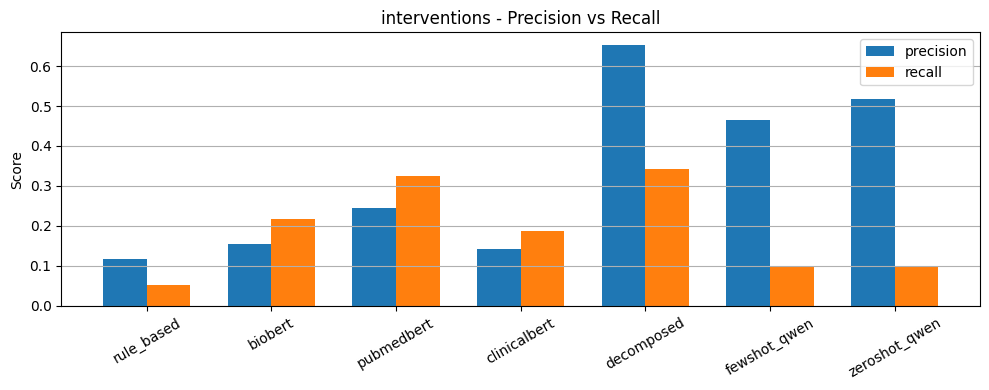

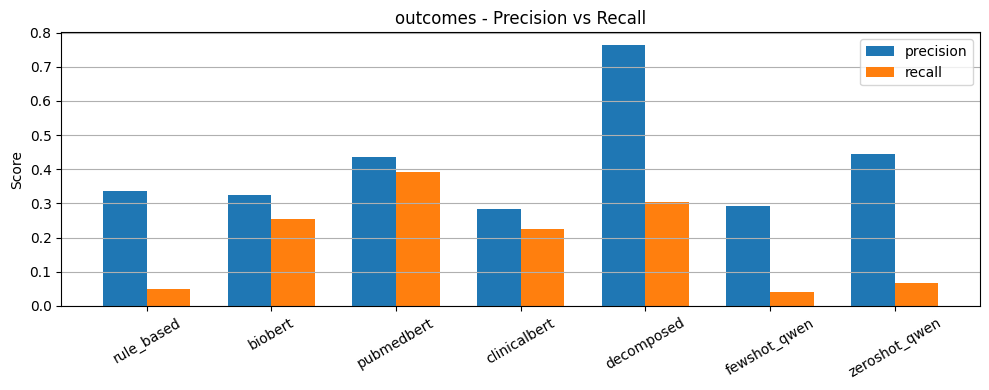

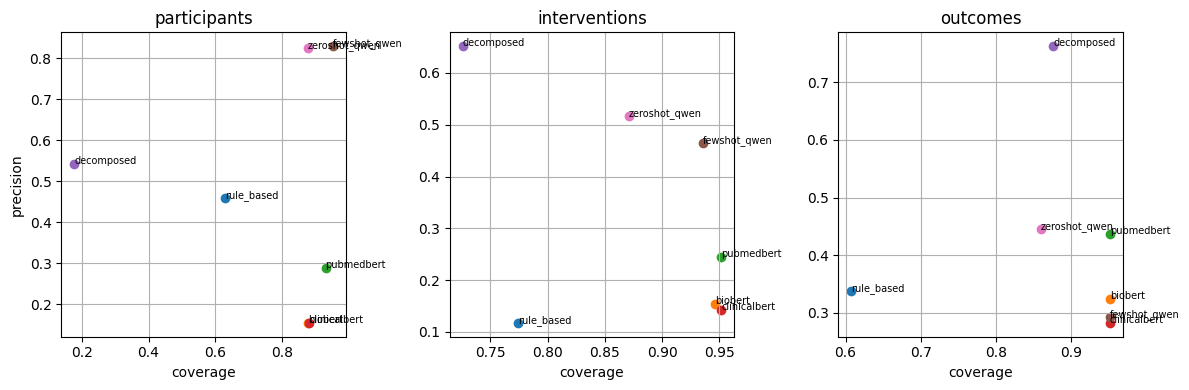

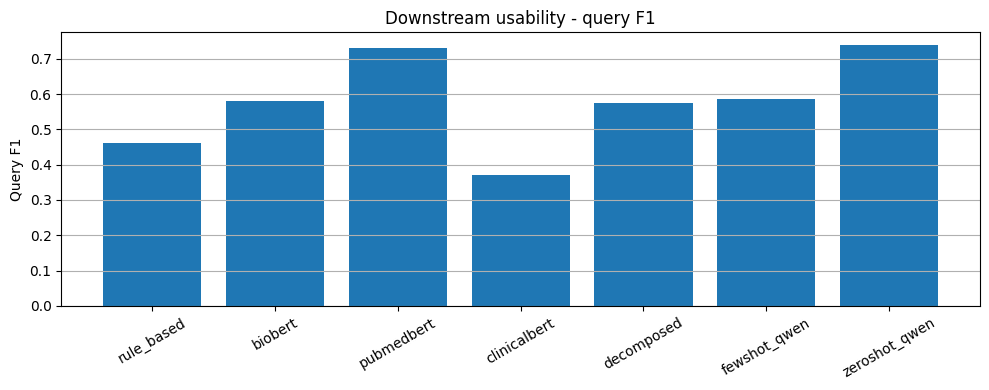

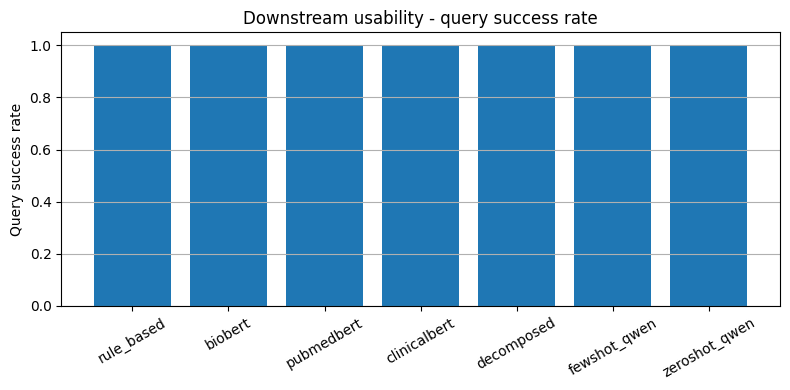

In [30]:

def plot_query_f1(query_scores):
    sub = query_scores[query_scores["query"] == "overall"].copy()
    sub["variant"] = pd.Categorical(sub["variant"], categories=model_order, ordered=True)
    sub = sub.sort_values("variant")

    plt.figure(figsize=(10,4))
    plt.bar(sub["variant"].astype(str), sub["f1"])

    plt.xticks(rotation=30)
    plt.ylabel("Query F1")
    plt.title("Downstream usability - query F1")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()


def plot_query_success(query_success):
    sub = query_success[query_success["query"] == "overall"].copy()
    sub["variant"] = pd.Categorical(sub["variant"], categories=model_order, ordered=True)
    sub = sub.sort_values("variant")

    plt.figure(figsize=(8,4))
    plt.bar(sub["variant"].astype(str), sub["success"])

    plt.xticks(rotation=30)
    plt.ylabel("Query success rate")
    plt.title("Downstream usability - query success rate")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

# ----------------------------
# queries
# ----------------------------
queries = [
    {"name":"diabetes participants","must_have":{"participants":["diabetes"]}},
    {"name":"exercise interventions","must_have":{"interventions":["exercise"]}},
    {"name":"blood pressure outcomes","must_have":{"outcomes":["blood pressure"]}},
    {"name":"diabetes and metformin","must_have":{"participants":["diabetes"],"interventions":["metformin"]}},
    {"name":"exercise and blood pressure","must_have":{"interventions":["exercise"],"outcomes":["blood pressure"]}}
]

query_score_all = eval_q_allvariant(all_runs, queries, top_k=10)
query_score_all["variant"] = pd.Categorical(query_score_all["variant"], categories=model_order, ordered=True)
query_score_all = query_score_all.sort_values(["query","variant"]).reset_index(drop=True)

query_success_all = eval_q_success_allvariant(all_runs, queries, top_k=10)
query_success_all["variant"] = pd.Categorical(query_success_all["variant"], categories=model_order, ordered=True)
query_success_all = query_success_all.sort_values(["query","variant"]).reset_index(drop=True)

table_query_all = query_score_all.pivot_table(
    index="query",
    columns="variant",
    values=["precision","recall","f1"],
    observed=False
)

display(table_query_all.round(3))

table_query_success = query_success_all.pivot_table(
    index="query",
    columns="variant",
    values="success",
    observed=False
)

display(table_query_success.round(3))

# ----------------------------
# run plots
# ----------------------------
plot_span_f1(field_scores)
plot_precision_recall(field_scores)
plot_cvp_simple(field_scores)
plot_query_f1(query_score_all)
plot_query_success(query_success_all)